In [136]:
import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.container import BarContainer

In [137]:
sns.set_style("whitegrid")
sns.set_palette(["#0072B2", "#D55E00"])  # Okabe–Ito blue (Python) / vermillion (Scala)

In [138]:
# Human-readable labels
IMPL_MAP = {
    "python": "Python",
    "scala": "Scala",
}
IMPL_ORDER = ["Python", "Scala"]

TARGET_MAP = {
    "json-schema": "JSON Schema",
    "shacl": "SHACL",
}
TARGET_ORDER = ["JSON Schema", "SHACL"]

df = (
    pl.read_parquet("../data/benchmarks.parquet")
    .with_columns(
        pl.col("runtime").replace_strict(IMPL_MAP).alias("Implementation"),
        pl.col("target").replace_strict(TARGET_MAP).alias("Target"),
        pl.col("schema").replace({"brigde2ai_model_card": "bridge2ai", "nmdc_microbiome": "nmdc"}).alias("Dataset"),
        pl.col("mean").alias("Throughput (ops/s)"),
    )
)
df.head()

harness,runtime,schema,target,mean,stddev,n,Implementation,Target,Dataset,Throughput (ops/s)
str,str,str,str,f64,f64,i64,str,str,str,f64
"""cli""","""scala""","""brigde2ai_model_card""","""json-schema""",198.961643,8.411667,50,"""Scala""","""JSON Schema""","""bridge2ai""",198.961643
"""cli""","""python""","""brigde2ai_model_card""","""json-schema""",1.595661,0.024501,50,"""Python""","""JSON Schema""","""bridge2ai""",1.595661
"""cli""","""scala""","""brigde2ai_model_card""","""shacl""",197.444068,8.27552,50,"""Scala""","""SHACL""","""bridge2ai""",197.444068
"""cli""","""python""","""brigde2ai_model_card""","""shacl""",1.55467,0.023737,50,"""Python""","""SHACL""","""bridge2ai""",1.55467
"""cli""","""scala""","""cdm""","""json-schema""",2.819112,0.049155,50,"""Scala""","""JSON Schema""","""cdm""",2.819112


In [139]:
def _fmt_speedup(r: float) -> str:
    return f"{r:.0f}×" if r >= 10 else f"{r:.1f}×"


def plot_scenario(harness: str, filename: str):
    data = df.filter(pl.col("harness") == harness).sort("Dataset")

    # (Target, Implementation, Dataset) -> mean / stddev
    mean_lookup, sd_lookup = {}, {}
    for r in data.iter_rows(named=True):
        key = (r["Target"], r["Implementation"], r["Dataset"])
        mean_lookup[key] = r["Throughput (ops/s)"]
        sd_lookup[key] = r["stddev"]

    py, scala = IMPL_ORDER  # "LinkML (Python)", "LinkML-Scala"

    fg = sns.catplot(
        data,
        kind="bar",
        x="Dataset",
        y="Throughput (ops/s)",
        hue="Implementation",
        hue_order=IMPL_ORDER,
        col="Target",
        col_order=TARGET_ORDER,
        errorbar=None,          # we draw stddev bars ourselves
        aspect=1.7,
        height=3.2,
    )

    for target, ax in zip(TARGET_ORDER, fg.axes.flat):
        ax.set_yscale("log")
        ax.set_ylim(top=ax.get_ylim()[1] * 1.5)  # headroom for the speedup labels
        xlabels = [t.get_text() for t in ax.get_xticklabels()]
        for cont, impl in zip(ax.containers, IMPL_ORDER):
            for i, (bar, ds) in enumerate(zip(cont, xlabels)):
                sd = sd_lookup.get((target, impl, ds))
                if sd is not None:
                    ax.errorbar(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height(),
                        yerr=sd,
                        fmt="none",
                        ecolor="black",
                        elinewidth=0.9,
                        capsize=2,
                    )
                # speedup label centred on the (taller) Scala bar
                if impl == scala:
                    py_mean = mean_lookup.get((target, py, ds))
                    scala_mean = mean_lookup.get((target, scala, ds))
                    if py_mean and scala_mean:
                        ax.annotate(
                            _fmt_speedup(scala_mean / py_mean),
                            (bar.get_x() + bar.get_width() / 2, scala_mean + (sd or 0)),
                            textcoords="offset points",
                            xytext=(0, 4),
                            ha="center",
                            va="bottom",
                            fontsize=10,
                            color="0.3",
                        )
        ax.set_xlabel("")
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha("right")
        # hug the outer bar groups: trim the axis-to-first-bar gap
        bars = [b for c in ax.containers if isinstance(c, BarContainer) for b in c]
        ax.set_xlim(min(b.get_x() for b in bars) - 0.15,
                    max(b.get_x() + b.get_width() for b in bars) + 0.15)

    # Drop the external legend and box it into the top-right of the last panel,
    # overlapping the axes so the bars can use the full figure width.
    if fg._legend is not None:
        fg._legend.remove()
    handles, labels = fg.axes.flat[-1].get_legend_handles_labels()
    fg.axes.flat[-1].legend(
        handles, labels,
        title="Implementation",
        loc="upper left",
        bbox_to_anchor=(0.93, 1.0),
        borderaxespad=0.0,
        frameon=True,
        framealpha=0.95,
        edgecolor="0.7",
    )

    fg.savefig(f"../img/{filename}.pdf", bbox_inches="tight", pad_inches=0.02)
    fg.savefig(f"../img/{filename}.svg", bbox_inches="tight", pad_inches=0.02)
    return fg

## Cold-start (CLI, end-to-end)

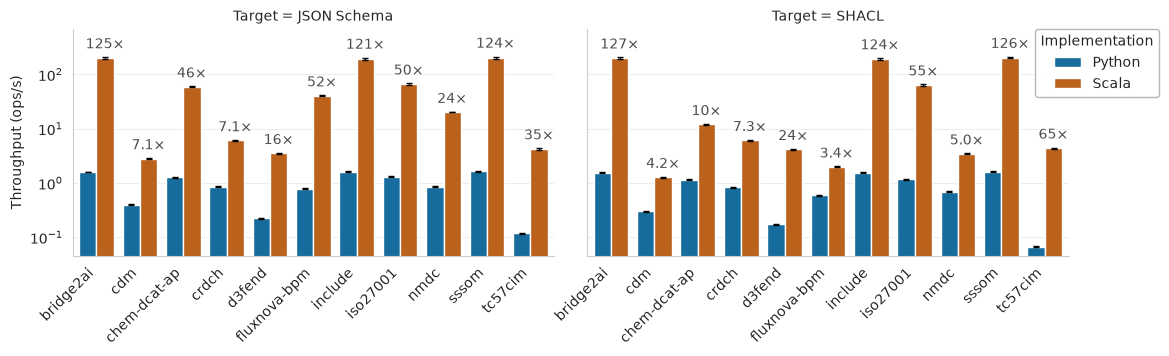

In [140]:
plot_scenario("cli", "throughput_cold")

## Warm (generation only)

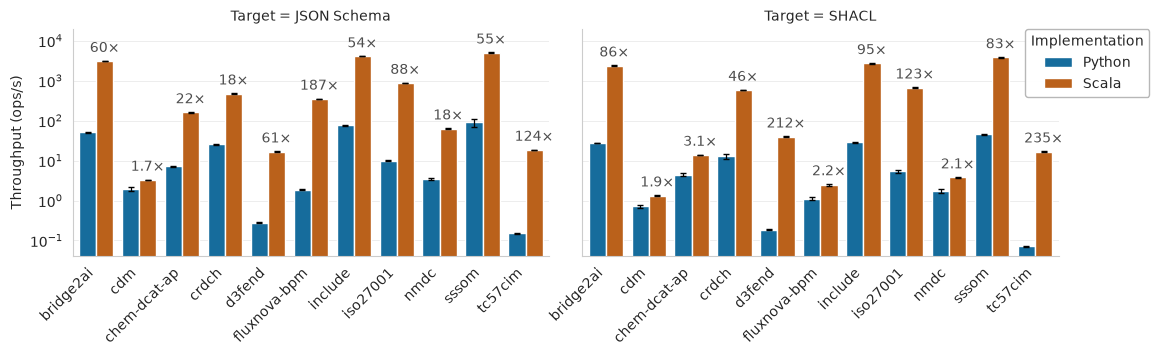

In [141]:
plot_scenario("jmh", "throughput_warm")

## Aggregate speedup

In [142]:
SCENARIO = {"cli": "cold", "jmh": "warm"}

speedup = (
    df.pivot(on="runtime", index=["harness", "target", "schema"], values="mean")
    .with_columns((pl.col("scala") / pl.col("python")).alias("speedup"))
)

(
    speedup.group_by("harness", "target")
    .agg(
        pl.col("speedup").log().mean().exp().round(1).alias("geomean"),
        pl.col("speedup").median().round(1).alias("median"),
        pl.col("speedup").min().round(1).alias("min"),
        pl.col("speedup").max().round(1).alias("max"),
        pl.len().alias("n"),
    )
    .with_columns(pl.col("harness").replace_strict(SCENARIO).alias("scenario"))
    .select("scenario", "target", "geomean", "median", "min", "max", "n")
    .sort("scenario", "target")
)

scenario,target,geomean,median,min,max,n
str,str,f64,f64,f64,f64,u32
"""cold""","""json-schema""",36.5,46.4,7.1,124.7,11
"""cold""","""shacl""",22.9,24.1,3.4,127.0,11
"""warm""","""json-schema""",38.5,55.2,1.7,187.4,11
"""warm""","""shacl""",26.8,83.4,1.9,235.4,11
